# Player Segmentation: Betting Volatility vs. Loss Chasing

Each dot is a player. The x-axis is how erratically a player's bet size swings from one bet to the next (**betting volatility**); the y-axis is how often they raise their bet right after a loss (**loss chasing rate**).

Players high on both axes show two concerning patterns at once, so they're flagged as at-risk. This is a small, human-readable preview of the kind of signal an XGBoost model would later learn to combine automatically.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from poker_coach.config import BUSTABIT_DATA_FILE, GRAPE_SODA, ROSY_GRANITE

sns.set_theme(style='darkgrid')

df = pd.read_csv(BUSTABIT_DATA_FILE, na_values=['NA'], parse_dates=['PlayDate'])
df['Won'] = df['CashedOut'].notna()   # missing CashedOut = player busted (lost)

df = df.sort_values(['Username', 'PlayDate']).reset_index(drop=True)  # each player's bets in time order
df['PrevBet'] = df.groupby('Username')['Bet'].shift(1)
df['PrevWon'] = df.groupby('Username')['Won'].shift(1)
df['BetIncreased'] = df['Bet'] > df['PrevBet']

seq_df = df.dropna(subset=['PrevBet', 'PrevWon']).copy()  # drop each player's first-ever bet (no history)
seq_df['PrevOutcome'] = seq_df['PrevWon'].map({True: 'After Win', False: 'After Loss'})
seq_df['LogBetRatio'] = np.log(seq_df['Bet'] / seq_df['PrevBet'])  # log so doubling and halving are equally "sized"

print(f"{len(seq_df):,} sequential bets across {seq_df['Username'].nunique():,} players")

45,851 sequential bets across 2,933 players


## Build `player_stats`

One row per player:

- **BettingVolatility** — standard deviation of `LogBetRatio` across all of a player's sequential bets. A player whose bet size barely moves bet-to-bet has volatility near 0; a player who's constantly doubling and halving their bet has high volatility.
- **LossChasingRate** — of the bets a player made *right after a loss*, the fraction where they raised their bet size. 0 = never chases, 1 = always chases.

Players are only kept if they have at least 10 after-loss bets, so both rates are estimated from enough data to be meaningful rather than noise from a player who's only played a handful of rounds.

In [2]:
MIN_AFTER_LOSS_BETS = 10  # need enough after-loss bets for a player's chasing rate to be meaningful

volatility = seq_df.groupby('Username')['LogBetRatio'].std().rename('BettingVolatility')

after_loss = seq_df[seq_df['PrevOutcome'] == 'After Loss']
loss_chasing = after_loss.groupby('Username')['BetIncreased'].agg(
    LossChasingRate='mean', NumAfterLossBets='size'
)

player_stats = loss_chasing.join(volatility, how='inner')
player_stats = player_stats[player_stats['NumAfterLossBets'] >= MIN_AFTER_LOSS_BETS].dropna()
player_stats = player_stats.reset_index()

print(f"{len(player_stats):,} players with at least {MIN_AFTER_LOSS_BETS} after-loss bets")
player_stats.describe()[['BettingVolatility', 'LossChasingRate']]

506 players with at least 10 after-loss bets


,BettingVolatility,LossChasingRate
count,506.000000,506.000000
mean,1.734943,0.401639
std,0.699841,0.139053
min,0.000000,0.000000
25%,1.281923,0.333333
50%,1.663501,0.416667
75%,2.104850,0.500000
max,4.712368,0.736842


## Scatterplot

A player is flagged **at-risk** only when they're in the top quartile on *both* metrics at once — high volatility alone, or high loss chasing alone, isn't the concerning combination.

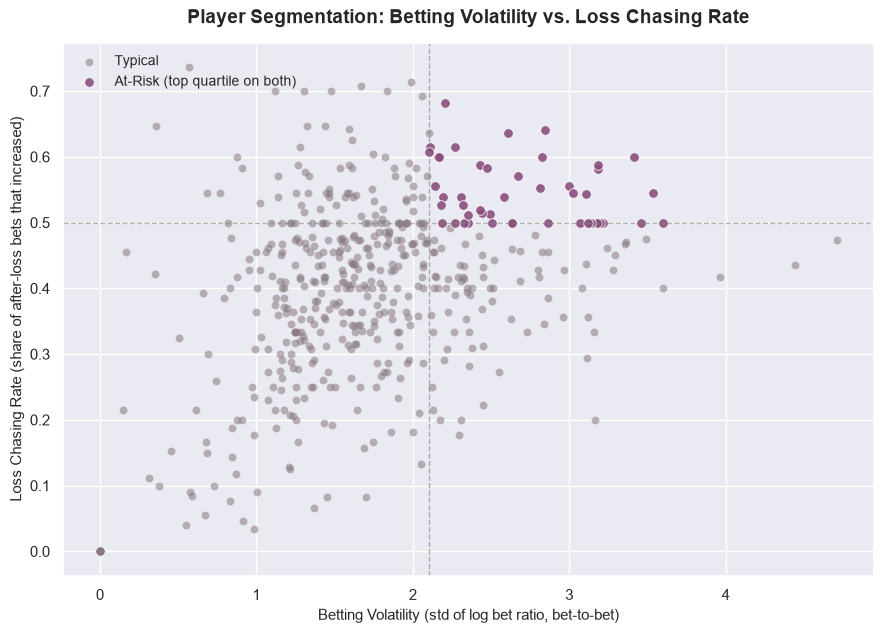

47 of 506 players (9.3%) flagged as at-risk


In [3]:
volatility_thresh = player_stats['BettingVolatility'].quantile(0.75)
chasing_thresh = player_stats['LossChasingRate'].quantile(0.75)

at_risk = (player_stats['BettingVolatility'] >= volatility_thresh) & (player_stats['LossChasingRate'] >= chasing_thresh)

fig, ax = plt.subplots(figsize=(9, 6.5))

ax.scatter(
    player_stats.loc[~at_risk, 'BettingVolatility'], player_stats.loc[~at_risk, 'LossChasingRate'],
    s=32, color=ROSY_GRANITE, alpha=0.55, linewidth=0, label='Typical'
)
ax.scatter(
    player_stats.loc[at_risk, 'BettingVolatility'], player_stats.loc[at_risk, 'LossChasingRate'],
    s=48, color=GRAPE_SODA, alpha=0.9, edgecolor='white', linewidth=0.6, label='At-Risk (top quartile on both)'
)

ax.axvline(volatility_thresh, color='0.5', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(chasing_thresh, color='0.5', linestyle='--', linewidth=1, alpha=0.6)

ax.set_title('Player Segmentation: Betting Volatility vs. Loss Chasing Rate', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Betting Volatility (std of log bet ratio, bet-to-bet)', fontsize=11)
ax.set_ylabel('Loss Chasing Rate (share of after-loss bets that increased)', fontsize=11)
ax.legend(frameon=False, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print(f"{at_risk.sum():,} of {len(player_stats):,} players ({at_risk.mean():.1%}) flagged as at-risk")